<div style="text-align:center; margin-top:45px;">

<img src="img/logoitqv1.jpg" width="600">

<h1 style="
font-family:'Times New Roman', serif;
font-size:42px;
font-weight:bold;
margin-top:30px;
margin-bottom:20px;
">

Programa3.Outliers

</h1>

<p style="
font-family:'Times New Roman', serif;
font-size:22px;
margin-top:15px;
">
September 23, 2026

</p>

<p style="
font-family:'Times New Roman', serif;
font-size:18px;
margin-top:45px;
">

<a href="https://github.com/kevinsuas433/Machine2026.git">
<strong>Link a mi GitHub</strong>
</a>

https://github.com/kevinsuas433/Machine2026.git

</p>

</div>

Kevin Suasnavas

---

# 0.1 Detección de Outliers

In [32]:
# ==========================================================
# Importación de librerías
# ==========================================================

# Pandas permite trabajar con estructuras de datos
# como DataFrames.
import pandas as pd

# NumPy permite realizar operaciones numéricas
# y trabajar con arreglos.
import numpy as np

# SciPy proporciona herramientas estadísticas
# que utilizaremos para el método Box Plot.
from scipy import stats

# EllipticEnvelope permite detectar valores atípicos
# utilizando una estimación de la distribución de los datos.
from sklearn.covariance import EllipticEnvelope

# Matplotlib permite crear y mostrar gráficos.
import matplotlib.pyplot as plt

In [33]:
# ==========================================================
# Carga de datos
# ==========================================================

# Cargamos el archivo CSV ubicado dentro de la carpeta dataset.
df = pd.read_csv("dataset/outliers.csv")

# Mostramos el contenido del DataFrame.
print(df)

            a         b
0    0.149014 -0.041479
1    0.194307  0.456909
2   -0.070246 -0.070241
3    0.473764  0.230230
4   -0.140842  0.162768
..        ...       ...
195 -5.114441  0.646251
196  5.631630  0.277174
197  1.552784  2.348984
198 -0.545507  1.530697
199  1.011772  4.813896

[200 rows x 2 columns]


## 0.1.1 1) EllipticEnvelope()

In [34]:
# ==========================================================
# 1) EllipticEnvelope
# ==========================================================

# Creamos un objeto EllipticEnvelope.
# contamination=0.25 indica que se espera aproximadamente
# un 25% de observaciones como posibles outliers.
# random_state=42 permite reproducir los resultados.
algorithm = EllipticEnvelope(
    support_fraction=None,
    contamination=0.25,
    random_state=42
)

# Entrenamos el algoritmo utilizando nuestro DataFrame.
outlier_method = algorithm.fit(df)

# Aplicamos el método entrenado sobre nuestro dataset.
# El resultado será:
#  1  -> dato normal
# -1  -> outlier
df_outliers = outlier_method.predict(df)

# Mostramos la clasificación obtenida.
print(df_outliers)

# Determinamos las posiciones de los outliers.
pos_outliers = np.where(df_outliers == -1)[0]

# Mostramos las posiciones de los outliers.
print('\nOutliers en la posición: \n', pos_outliers)

# Determinamos y mostramos el número de outliers.
print('\nNúmero de outliers: \n', len(pos_outliers))

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1]

Outliers en la posición: 
 [150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167
 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185
 186 187 188 189 190 191 192 193 194 195 196 197 198 199]

Número de outliers: 
 50


In [36]:
# ==========================================================
# Función para detectar outliers
# ==========================================================

# Definimos una función que recibe:
# - df: conjunto de datos
# - algorithm: algoritmo que utilizaremos
#
# La función devuelve:
# - df_outliers: clasificación de cada registro
# - pos_outliers: posiciones de los outliers
def find_outliers(df, algorithm):

    # Entrenamos el algoritmo con nuestro dataset.
    outlier_method = algorithm.fit(df)

    # Aplicamos el método entrenado sobre nuestro dataset.
    #  1 representa un dato normal.
    # -1 representa un outlier.
    df_outliers = outlier_method.predict(df)

    # Mostramos la clasificación obtenida.
    print(df_outliers)

    # Determinamos las posiciones de los outliers.
    pos_outliers = np.where(df_outliers == -1)[0]

    # Mostramos las posiciones encontradas.
    print('\nOutliers en la posición :\n', pos_outliers)

    # Mostramos el número de outliers.
    print('\nNúmero de outliers: \n', len(pos_outliers))

    # Devolvemos los dos resultados.
    return df_outliers, pos_outliers

## 0.1.2 2) Otros métodos similares

In [44]:
# ==========================================================
# Otros métodos de detección de outliers
# ==========================================================

# Importamos Isolation Forest.
from sklearn.ensemble import IsolationForest

# Importamos One-Class SVM.
from sklearn.svm import OneClassSVM

# Importamos Local Outlier Factor.
from sklearn.neighbors import LocalOutlierFactor

# Creamos el modelo Isolation Forest.
# max_samples='auto' permite determinar automáticamente
# el número de muestras utilizadas.
# random_state=42 permite reproducir los resultados.
IF = IsolationForest(
    max_samples='auto',
    random_state=42
)

# OC_SVM = ??
# LOF = ??

# Aplicamos Isolation Forest mediante nuestra función.
df_outliers, pos_outliers = find_outliers(df, IF)

# Mostramos el número de outliers encontrados.
print(len(pos_outliers))

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1  1 -1]

Outliers en la posición :
 [150 151 152 153 154 155 156 157 158 159 160 161 162 163 165 166 167 168
 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186
 187 188 189 190 191 192 193 194 195 196 197 199]

Número de outliers: 
 48
48


In [38]:
# ==========================================================
# Visualización de las primeras filas
# ==========================================================

# Mostramos las primeras 10 filas del dataset
# para observar sus valores.
df.head(10)

,a,b
0,0.149014,-0.041479
1,0.194307,0.456909
2,-0.070246,-0.070241
3,0.473764,0.230230
4,-0.140842,0.162768
5,-0.139025,-0.139719
6,0.072589,-0.573984
7,-0.517475,-0.168686
8,-0.303849,0.094274
9,-0.272407,-0.423691


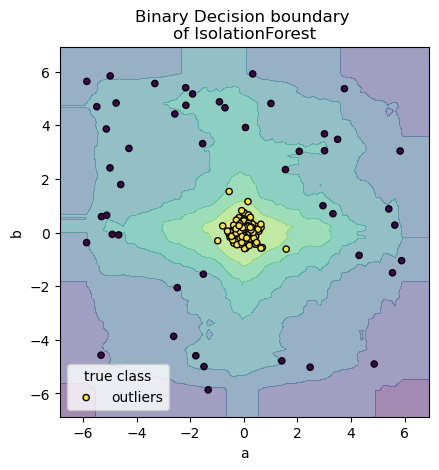

In [39]:
# ==========================================================
# Frontera de decisión de Isolation Forest
# ==========================================================

# Importamos la herramienta que permite visualizar
# la frontera de decisión de un modelo.
from sklearn.inspection import DecisionBoundaryDisplay

# Generamos la frontera de decisión utilizando
# el modelo Isolation Forest.
disp = DecisionBoundaryDisplay.from_estimator(
    IF,
    df,
    response_method="decision_function",
    alpha=0.5,
)

# Dibujamos los puntos del dataset.
# df_outliers contiene:
#  1  -> datos normales
# -1  -> outliers
disp.ax_.scatter(
    df.a,
    df.b,
    c=df_outliers,
    s=20,
    edgecolor="k"
)

# Colocamos el título del gráfico.
disp.ax_.set_title(
    "Binary Decision boundary \nof IsolationForest"
)

# Hacemos que los ejes tengan la misma escala.
plt.axis("square")

# Agregamos la leyenda.
plt.legend(
    labels=["outliers", "inliers"],
    title="true class"
)

# Mostramos el gráfico.
plt.show()

In [40]:
# ==========================================================
# Eliminación de los outliers
# ==========================================================

# Conservamos solamente los registros clasificados
# como normales por Isolation Forest.
# El valor 1 representa un dato normal.
new_df = df[df_outliers == 1]

# Mostramos el nuevo DataFrame.
print(new_df)

            a         b
0    0.149014 -0.041479
1    0.194307  0.456909
2   -0.070246 -0.070241
3    0.473764  0.230230
4   -0.140842  0.162768
..        ...       ...
147  0.107105 -0.207873
148  0.269880  0.092190
149  0.243859  0.188889
164  1.582047 -0.618654
198 -0.545507  1.530697

[152 rows x 2 columns]


## 0.1.3 3) Box plot

limite inferior:  -1.0853060827395105
limite superior:  1.0119554520872196
Posición de outliers:  [150 153 154 157 159 160 162 165 168 169 171 172 174 175 177 178 181 184
 185 186 187 190 191 192 193 195 151 152 155 156 161 163 164 166 167 173
 176 179 180 182 188 189 196 197]
Número de outliers:  44


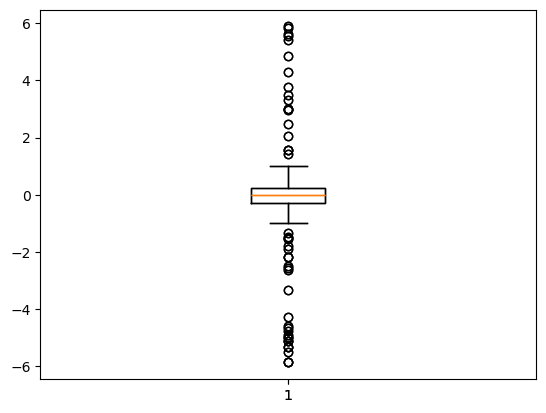

In [41]:
# ==========================================================
# 3) Box Plot
# ==========================================================

# Seleccionamos el atributo que vamos a analizar.
a = df['a']

# Calculamos el primer cuartil (Q1),
# correspondiente al percentil 25.
Q1 = stats.scoreatpercentile(a, 25)

# Calculamos el tercer cuartil (Q3),
# correspondiente al percentil 75.
Q3 = stats.scoreatpercentile(a, 75)

# Calculamos el rango intercuartílico (RIC).
RIC = Q3 - Q1

# Calculamos el límite inferior.
li = Q1 - 1.5 * RIC

# Calculamos el límite superior.
ls = Q3 + 1.5 * RIC

# Mostramos los límites calculados.
print('limite inferior: ', li)
print('limite superior: ', ls)

# Buscamos los valores que están por debajo
# del límite inferior.
pos_i = np.where(a < li)[0]

# Buscamos los valores que están por encima
# del límite superior.
pos_s = np.where(a > ls)[0]

# Unimos las posiciones de ambos grupos.
pos_outliers = np.concatenate((pos_i, pos_s))

# Mostramos las posiciones de los outliers.
print('Posición de outliers: ', pos_outliers)

# Mostramos el número de outliers.
print('Número de outliers: ', len(pos_outliers))

# Dibujamos el diagrama de caja y bigotes.
prop = plt.boxplot(a)

# Dibujamos el Box Plot.
plt.boxplot(a)

# Mostramos el gráfico.
plt.show()

In [42]:
# ==========================================================
# Función para detectar outliers mediante Box Plot
# ==========================================================

# Definimos una función que recibe una columna
# de un DataFrame y devuelve las posiciones
# de los outliers encontrados mediante Box Plot.
def find_limits_BP(variable):

    # Calculamos el primer cuartil.
    Q1 = stats.scoreatpercentile(variable, 25)

    # Calculamos el tercer cuartil.
    Q3 = stats.scoreatpercentile(variable, 75)

    # Calculamos el rango intercuartílico.
    RIC = Q3 - Q1

    # Calculamos el límite inferior.
    li = Q1 - 1.5 * RIC

    # Calculamos el límite superior.
    ls = Q3 + 1.5 * RIC

    # Buscamos las posiciones de los valores
    # inferiores al límite inferior.
    pos_i = np.where(variable < li)[0]

    # Buscamos las posiciones de los valores
    # superiores al límite superior.
    pos_s = np.where(variable > ls)[0]

    # Unimos las posiciones de ambos grupos.
    pos_outliers = np.concatenate((pos_i, pos_s))

    # Devolvemos las posiciones encontradas.
    return pos_outliers

In [43]:
# ==========================================================
# Detección de outliers en todos los atributos
# ==========================================================

# Obtenemos los nombres de todos los atributos
# existentes en el DataFrame.
headers = df.columns

# Creamos una lista para almacenar los outliers
# encontrados en cada atributo.
pos_outliers = []

# Recorremos todos los atributos del DataFrame.
for i in range(len(headers)):

    # Seleccionamos el atributo actual.
    variable = df[headers[i]]

    # Aplicamos la función de Box Plot
    # a la variable seleccionada.
    pos_out = np.expand_dims(
        find_limits_BP(variable),
        axis=1
    )

    # Guardamos las posiciones encontradas.
    pos_outliers.append(pos_out)

# Concatenamos todas las posiciones de outliers.
po = np.vstack(pos_outliers)

# Eliminamos posiciones repetidas.
pos_out = np.unique(po)

# Mostramos las posiciones de todos los outliers.
print('Posiciones de outliers: ', pos_out)

# Mostramos el número total de posiciones encontradas.
print('Numero de outliers: ', len(pos_out))

Posiciones de outliers:  [104 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166
 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184
 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199]
Numero de outliers:  51


# Ejercicios

In [48]:
# Creamos el modelo Isolation Forest.
# Este algoritmo permite detectar valores atípicos
# mediante el aislamiento de observaciones.
IF = IsolationForest(
    max_samples='auto',
    random_state=42
)

# Creamos el modelo One-Class SVM.
# Se utiliza para identificar observaciones que
# se comportan de manera diferente al resto de los datos.
OC_SVM = OneClassSVM(
    kernel='rbf',
    gamma='scale',
    nu=0.25
)

# Creamos el modelo Local Outlier Factor (LOF).
# Este método identifica valores atípicos comparando
# la densidad local de cada observación con la de sus vecinos.
LOF = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.25
)

# Aplicamos Isolation Forest al conjunto de datos.
# La función devuelve las etiquetas de los datos
# y las posiciones donde se encuentran los outliers.
df_outliers, pos_outliers = find_outliers(df, IF)

# Mostramos el número de outliers encontrados.
print("Número de outliers con Isolation Forest:", len(pos_outliers))

# Aplicamos One-Class SVM al conjunto de datos.
df_outliers_svm, pos_outliers_svm = find_outliers(df, OC_SVM)

# Mostramos el número de outliers encontrados.
print("Número de outliers con One-Class SVM:", len(pos_outliers_svm))

# Aplicamos Local Outlier Factor.
# LOF utiliza fit_predict() para clasificar directamente
# cada observación como normal (1) o outlier (-1).
df_outliers_lof = LOF.fit_predict(df)

# Obtenemos las posiciones de los valores atípicos.
pos_outliers_lof = np.where(df_outliers_lof == -1)[0]

# Mostramos el número de outliers encontrados.
print("Número de outliers con LOF:", len(pos_outliers_lof))

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1  1 -1]

Outliers en la posición :
 [150 151 152 153 154 155 156 157 158 159 160 161 162 163 165 166 167 168
 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186
 187 188 189 190 191 192 193 194 195 196 197 199]

Número de outliers: 
 48
Número de outliers con Isolation Forest: 48
[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  